In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def readcsv(file_path):
    try:
        data = pd.read_csv(file_path, index_col=0)
        return data
    except Exception as e:
        print(f"Error reading CSV file: {e}")
        return None

In [2]:
df_timelapse = readcsv("Report_1/Analysis.csv")

df_timelapse.head()

,frame,label,Area,Perimeter,Eccentricity,Baseline,Cell Median,Membrane Median,Septum Median,Cytoplasm Median,Fluor Ratio,Fluor Ratio 75%,Fluor Ratio 25%,Fluor Ratio 10%,Cell Cycle Phase,DNA Ratio
0,0,1,57.0,32.485281,0.945657,1796.0,3453.0,3278.0,0,4054.0,0,0,0,0,0,NaN
1,0,2,278.0,61.213203,0.716953,2071.0,4502.5,3196.0,0,4646.5,0,0,0,0,0,NaN
2,0,3,168.0,52.142136,0.905307,1600.0,3494.0,2848.5,0,4035.5,0,0,0,0,0,NaN
3,0,4,59.0,30.142136,0.892107,1942.0,3076.0,2847.5,0,3481.0,0,0,0,0,0,NaN
4,0,5,251.0,60.627417,0.543251,1480.0,3721.0,3721.0,0,3725.5,0,0,0,0,0,NaN


In [3]:
def plot_selected_data(df, property, labels, mean):

    # Filter the DataFrame to include only the selected labels
    df_filtered = df[df['label'].isin(labels)]
    
    # Create a line plot of Area for each label over the different frames
    fig = plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_filtered, x='frame', y=property, hue='label', marker='o', palette='tab10')
    if mean:
        # add a line thats the average of all the labels
        sns.lineplot(data=df.groupby('frame')[property].mean().reset_index(), x='frame', y=property, color='black', label='Average', linestyle='--')
    plt.title(f'{property} of Selected Labels Over Time')
    plt.xlabel('Frame')
    plt.ylabel(f'{property} Fluorescence Intensity (A.U.)')
    plt.legend(title='Label')

    return fig

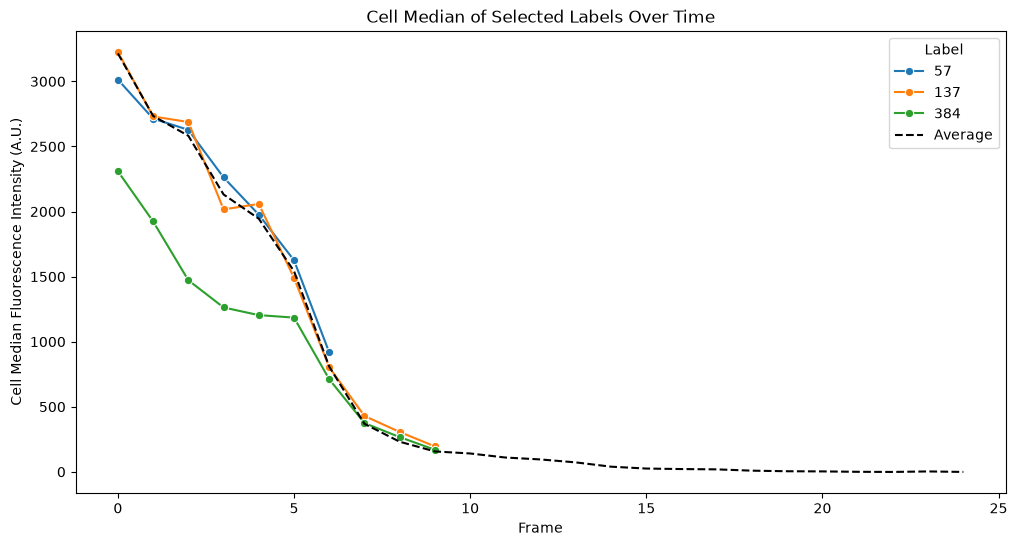

In [4]:
# Select 6 labels
labels_to_plot = [57, 137, 384]

f = plot_selected_data(df_timelapse, property='Cell Median', labels=labels_to_plot, mean=True)
plt.show()

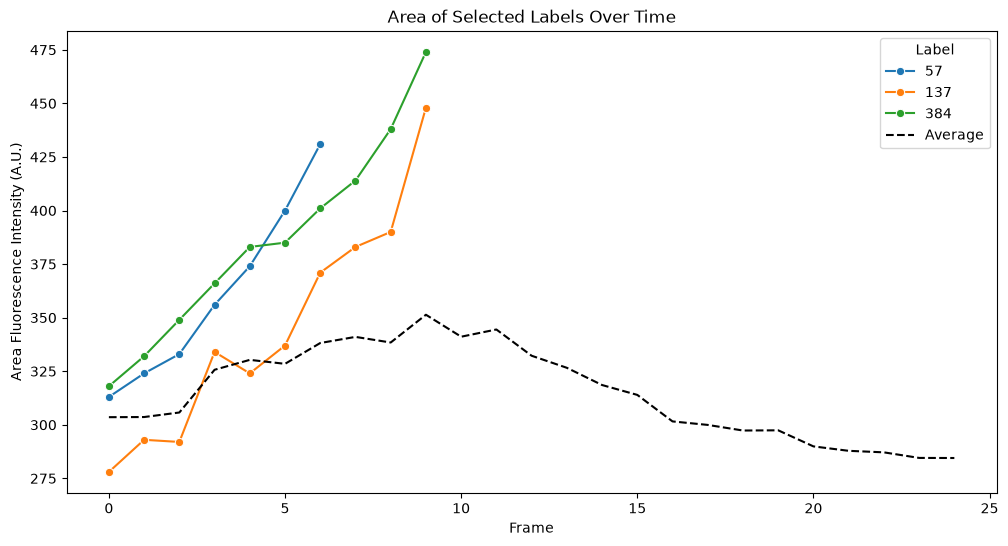

In [5]:

f = plot_selected_data(df_timelapse, property='Area', labels=labels_to_plot, mean=True)
plt.show()

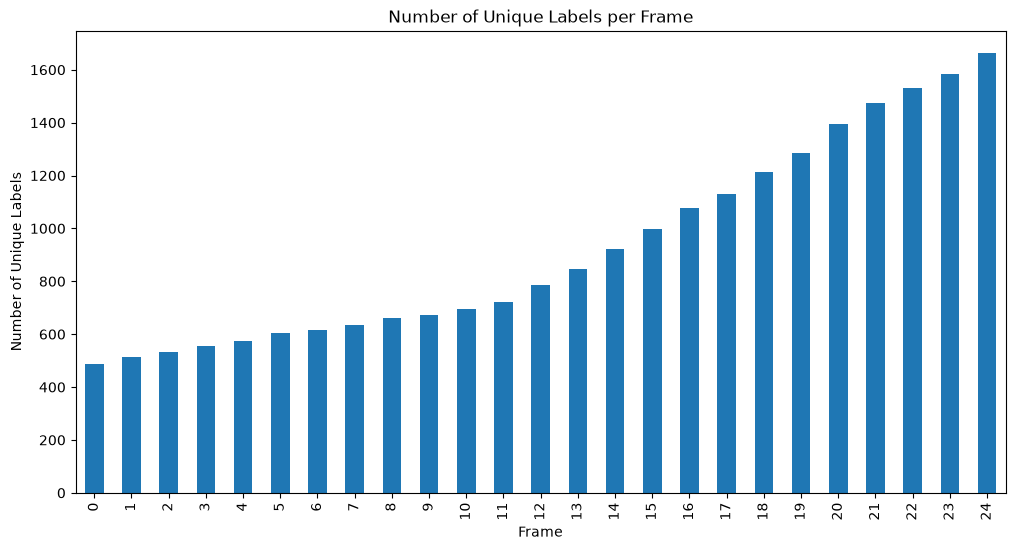

In [6]:
# number of elements in each timepoint
df_timelapse.groupby('frame')['label'].nunique().plot(kind='bar', figsize=(12, 6))
plt.title('Number of Unique Labels per Frame')
plt.xlabel('Frame')
plt.ylabel('Number of Unique Labels')
plt.show()

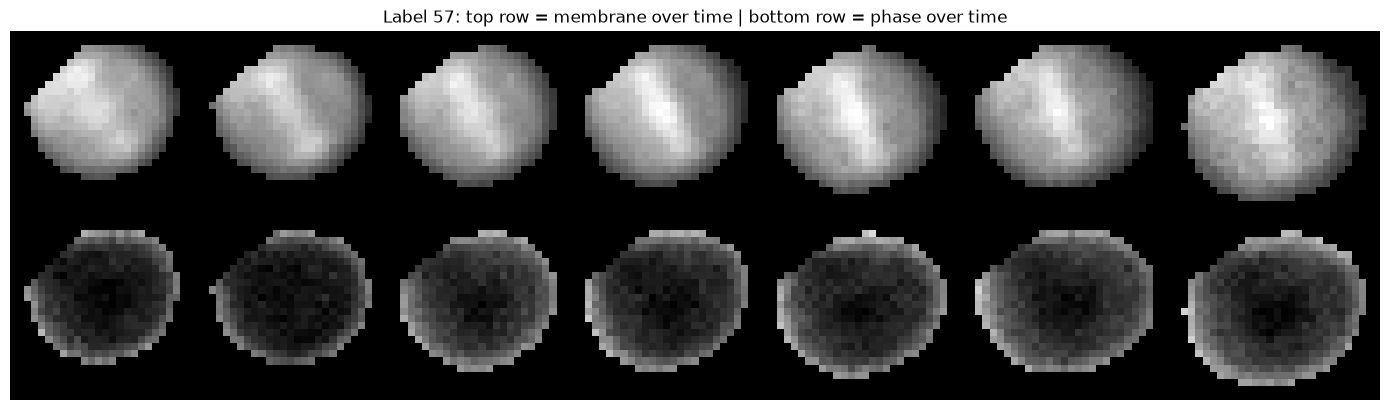

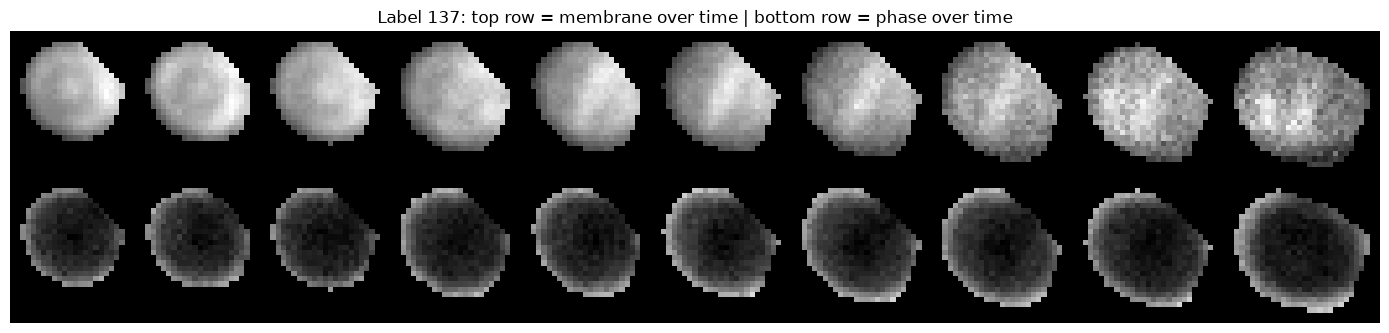

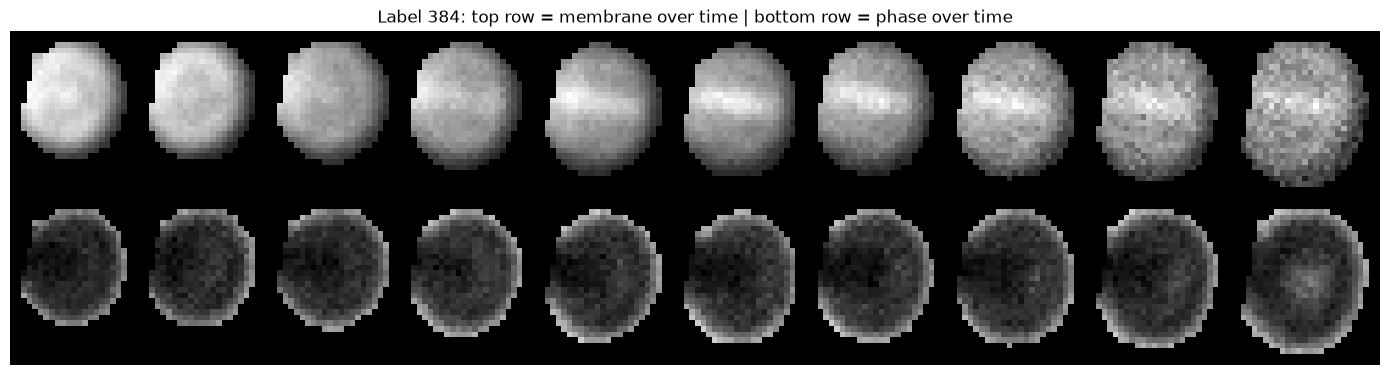

In [7]:
import tifffile
import numpy as np
import matplotlib.pyplot as plt
from skimage.exposure import rescale_intensity

labels = tifffile.imread("Labels.tif")
phase = tifffile.imread("Phase_Registered.tif")
memb = tifffile.imread("NR_Registered.tif")


def make_label_time_mosaic_two_rows(labels, phase, memb, label, pad=2):
    """
    Build a two-row mosaic for one label from 3D arrays (t, y, x):
    - Row 1: membrane over time
    - Row 2: phase over time

    Each frame is cropped to that label's bounding box, background is masked out,
    and each crop is rescaled independently.
    """

    if labels.ndim != 3 or phase.ndim != 3 or memb.ndim != 3:
        raise ValueError("labels, phase, and memb must be 3D arrays with shape (t, y, x)")

    if labels.shape != phase.shape or labels.shape != memb.shape:
        raise ValueError("labels, phase, and memb must have the same shape")

    phase_tiles = []
    memb_tiles = []

    for t in range(labels.shape[0]):
        mask = labels[t] == label
        if not np.any(mask):
            continue

        ys, xs = np.where(mask)
        y0 = max(0, ys.min() - pad)
        y1 = min(labels.shape[1], ys.max() + 1 + pad)
        x0 = max(0, xs.min() - pad)
        x1 = min(labels.shape[2], xs.max() + 1 + pad)

        mask_crop = mask[y0:y1, x0:x1]
        phase_crop = rescale_intensity(phase[t, y0:y1, x0:x1]) * mask_crop
        memb_crop = rescale_intensity(memb[t, y0:y1, x0:x1]) * mask_crop

        phase_tiles.append(phase_crop)
        memb_tiles.append(memb_crop)

    if not phase_tiles:
        return None

    max_h = max(tile.shape[0] for tile in phase_tiles)

    def _pad_to_height(tile, target_h):
        h, _ = tile.shape
        if h < target_h:
            return np.pad(tile, ((0, target_h - h), (0, 0)), mode="constant")
        return tile

    phase_row = np.concatenate([_pad_to_height(tile, max_h) for tile in phase_tiles], axis=1)
    memb_row = np.concatenate([_pad_to_height(tile, max_h) for tile in memb_tiles], axis=1)

    return np.concatenate([memb_row, phase_row], axis=0)


def build_mosaics_for_labels(labels, phase, memb, label_list, pad=2):
    """Build two-row mosaics for multiple labels. Returns {label: mosaic_or_None}."""
    mosaics = {}
    for lab in label_list:
        mosaics[lab] = make_label_time_mosaic_two_rows(labels, phase, memb, lab, pad=pad)
    return mosaics


labels_to_show = [57,137,384]
mosaics = build_mosaics_for_labels(labels, phase, memb, labels_to_show, pad=2)

for lab, mos in mosaics.items():
    if mos is None:
        print(f"Label {lab} not found in any frame.")
        continue

    plt.figure(figsize=(14, 5))
    plt.imshow(mos, cmap="gray", vmin=0, vmax=1)
    plt.title(f"Label {lab}: top row = membrane over time | bottom row = phase over time")
    plt.axis("off")
    plt.tight_layout()
    plt.show()